# `logit_mle` tutorial: mixed logit and HHO nonparametric random coefficients

This notebook walks a new user through the package end to end: the data format, the
integration machinery, mixed-logit MLE, the fixed-grid (FKRB/HHO) nonparametric
estimator with cross-validated regularization, and how to read off substitution
patterns (diversion and elasticities). We lean on simulation throughout so that we
always have a **known truth** to compare against.

**How to run.** The package core is `numpy / scipy / jax`. This tutorial also needs the
`hho` extra (cvxpy) and the `examples` extra (matplotlib, jupytext, ...). From a clone:

```bash
uv run --with ".[hho,examples]" jupytext --to notebook --execute examples/tutorial.py
```

or open `examples/tutorial.ipynb` in Jupyter after `uv pip install -e ".[hho,examples]"`.

**Conventions cheat-sheet** (memorize these — they prevent the most common mistakes):

- Dimensions are `(J, T)` = products × markets. `J` **includes the outside good**.
- The **outside good is the last row/column** (index `J-1`), with utility normalized to 0.
- `availability_matrix` is `(J, T)` boolean; `q_jt` is `(J, T)` purchase **counts**.
- Product characteristics `x2` are `(J, G)` — `G` random-coefficient characteristics.
- JAX runs in float64 here; every stochastic routine takes an explicit `seed`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from logit_mle import (
    Logit, NestedLogit, RandomCoefficients, FixedGridRC,
    halton_draws, sparse_grid, beta_grid_box,
)

import contextlib
import io

rng_seed = 2025
np.set_printoptions(precision=3, suppress=True)


@contextlib.contextmanager
def quiet():
    """Silence the per-construction info prints from the model constructors."""
    with contextlib.redirect_stdout(io.StringIO()):
        yield

## 1. The data format

A discrete-choice dataset here is three aligned arrays over products `j = 0..J-1`
(last = outside good) and markets `t = 0..T-1`:

- `availability_matrix` $(J,T)$ — is product $j$ offered in market $t$?
- `q_jt` $(J,T)$ — observed purchase **counts** (the outside good's row is non-purchases).
- `x2` $(J,G)$ — product characteristics that may carry random coefficients.

Observed **market shares** are formed by normalizing counts within each market,
$s^{\text{obs}}_{jt} = q_{jt} / \sum_{k} q_{kt}$, so each market's shares (inside + outside)
sum to one. "A market" is just a choice situation with its own availability and shares —
a city, a week, a city-month, etc.

Here is a tiny hand-built example to make the shapes concrete.

In [2]:
J, T = 4, 3                       # 3 inside goods + outside; 3 markets
avail = np.ones((J, T), dtype=bool)
avail[2, 0] = False              # product 2 not offered in market 0
q_jt = np.array([
    [40, 35, 10],                # product 0
    [25, 30, 55],                # product 1
    [0, 20, 15],                 # product 2 (0 where unavailable)
    [35, 15, 20],                # outside good (last row)
], dtype=float)
shares = q_jt / q_jt.sum(axis=0, keepdims=True)
print("observed shares (columns sum to 1):\n", shares)
print("column sums:", shares.sum(axis=0))

observed shares (columns sum to 1):
 [[0.4  0.35 0.1 ]
 [0.25 0.3  0.55]
 [0.   0.2  0.15]
 [0.35 0.15 0.2 ]]
column sums: [1. 1. 1.]


## 2. Integration rules

Mixed logit integrates over a distribution of consumer tastes. Numerically we replace the
expectation by a weighted sum over nodes $\nu_i \in \mathbb{R}^G$ with weights $w_i$,

$$
\mathbb{E}_{\nu}\!\big[h(\nu)\big] \;=\; \int h(\nu)\,\phi(\nu)\,d\nu \;\approx\; \sum_{i=1}^{I} w_i\, h(\nu_i),
$$

where $\phi$ is the standard multivariate normal. The package gives two ways to build
$(\nu_i, w_i)$:

- **`halton_draws(G, n)`** — scrambled quasi-Monte-Carlo (Halton → inverse-normal),
  equal weights $w_i = 1/n$. Robust across regimes; the recommended default, especially
  for larger $G$.
- **`sparse_grid(G, order)`** — deterministic Genz–Keister sparse quadrature (needs the
  `sparse` extra, `chaospy`). Fewer nodes for small $G$ and modest heterogeneity.

Both produce *integration rules* for $\mathbb{E}_\nu$. **Do not confuse them with**
`beta_grid_box` (Section 4), which builds a *coverage grid* of coefficient values for the
nonparametric estimator — different object, no weights.

In [3]:
nu_h, w_h = halton_draws(G=2, n=1000, seed=42)
print("halton:", nu_h.shape, "weights sum =", w_h.sum())

# A sanity check: the integration rule reproduces a known moment, E[nu_g^2] = 1.
print("E[nu^2] (should be ~1):", (w_h[:, None] * nu_h**2).sum(axis=0))

try:
    nu_s, w_s = sparse_grid(G=2, order=3)
    print("sparse_grid:", nu_s.shape, "weights sum =", w_s.sum())
except ImportError:
    print("sparse_grid needs the 'sparse' extra (chaospy) — skipping")

halton: (1000, 2) weights sum = 1.0000000000000004
E[nu^2] (should be ~1): [0.999 1.003]
sparse_grid needs the 'sparse' extra (chaospy) — skipping


## 3. Mixed logit by maximum likelihood

**The model.** Consumer $i$ in market $t$ gets utility from product $j$

$$
u_{ijt} \;=\; \underbrace{\delta_{jt}}_{\text{mean utility}} \;+\; \sum_{g=1}^{G} x_{jg}\,\sigma_g\,\nu_{ig} \;+\; \varepsilon_{ijt},
\qquad \nu_i \sim N(0, I_G),\ \ \varepsilon_{ijt} \sim \text{T1EV}.
$$

The **mean taste** for characteristics is absorbed into $\delta_{jt}$; the random part is
the deviation $\beta_{ig} = \sigma_g\,\nu_{ig}$, so $\sigma_g$ is the standard deviation of
the taste for characteristic $g$. The outside good ($j = J-1$) has $u_{i,J-1,t} = \xi_t +
\varepsilon$ (with $\xi_t = 0$ when there are no market fixed effects). Given T1EV errors,
individual choice probabilities are logit, and market shares integrate over tastes:

$$
s_{ijt} = \frac{\exp\{\delta_{jt} + \sum_g x_{jg}\sigma_g\nu_{ig}\}}
                {\sum_{k} \exp\{\delta_{kt} + \sum_g x_{kg}\sigma_g\nu_{ig}\}},
\qquad
s_{jt} = \int s_{ijt}\,dF(\nu) \approx \sum_i w_i\, s_{ijt}.
$$

We estimate $\theta = (\delta, \sigma)$ (and $\xi$ with market FE) by **maximum
likelihood** on the observed counts,
$\;\max_\theta \sum_{j,t} q_{jt}\log s_{jt}(\theta)$, via L-BFGS over a JAX likelihood.

**Parameter layout** (`theta`): `delta[J-1]` (inside-good mean utilities; outside = 0),
then `sigma[G]`, then `xi[T-1]` if `market_fe=True`.

We simulate from this exact model so we can check recovery. The helper below draws a
normal-RC DGP with **availability variation across markets** (the clean source of
identification) and **sampling noise** (finite consumers per market).

In [4]:
def simulate(J_in, T, G, *, n_draws=1000, n_cons=500, avail_p=0.85,
             market_fe=False, seed=0):
    """Simulate a normal random-coefficients market with availability variation + noise."""
    rng = np.random.RandomState(seed)
    J = J_in + 1
    x2 = rng.randn(J, G)
    x2[J - 1] = 0.0                                   # outside good characteristics = 0
    avail = rng.rand(J, T) < avail_p
    avail[J - 1, :] = True                            # outside always available
    for t in range(T):                                # >= 2 inside goods per market
        if avail[:J - 1, t].sum() < 2:
            avail[rng.choice(J - 1, 2, replace=False), t] = True

    nu, w = halton_draws(G, n_draws, seed=1)
    delta_true = rng.uniform(-2.5, -1.0, J_in)
    sigma_true = rng.uniform(0.5, 1.2, G)
    xi = np.zeros(T)
    if market_fe:
        xi = rng.uniform(-0.5, 0.5, T)
        xi[-1] = 0.0
    parts = [delta_true, sigma_true] + ([xi[:-1]] if market_fe else [])
    theta_true = np.concatenate(parts)

    with quiet():
        truth = RandomCoefficients(avail, x2=x2, nu_i=nu, w_i=w, market_fe=market_fe)
    s_true = np.asarray(truth.shares(theta_true))     # (J, T)
    q = np.empty_like(s_true)                         # multinomial counts per market
    for t in range(T):
        col = s_true[:, t] / s_true[:, t].sum()
        q[:, t] = rng.multinomial(n_cons, col)
    D_true = np.asarray(truth.diversion_matrix(theta_true))

    return dict(J=J, J_in=J_in, T=T, G=G, x2=x2, avail=avail, nu=nu, w=w,
                sigma_true=sigma_true, theta_true=theta_true, q=q, s_true=s_true,
                D_true=D_true, truth=truth, market_fe=market_fe)


sim = simulate(J_in=8, T=60, G=2, seed=0)
print("J =", sim["J"], " T =", sim["T"], " G =", sim["G"])
print("true sigma:", sim["sigma_true"])

J = 9  T = 60  G = 2
true sigma: [0.622 0.772]


In [5]:
# Fit the mixed logit by MLE.
rc = RandomCoefficients(sim["avail"], sim["q"], x2=sim["x2"],
                        nu_i=sim["nu"], w_i=sim["w"], market_fe=False)
step1 = rc.fit(seed=rng_seed, verbose=False)
sigma_hat = rc._unpack_theta(step1.x)["sigma"]
print("true sigma :", sim["sigma_true"])
print("MLE  sigma :", np.asarray(sigma_hat))

RCN
I (Individuals):   1000
J (Products):      9
T (Markets):       60
G (Random Coeffs): 2


true sigma : [0.622 0.772]
MLE  sigma : [0.67 0.82]


The estimated $\sigma$ should be in the neighborhood of the truth (it is recovered from
how substitution responds to the configuration of available products across markets).
We'll judge the fit by *substitution* — the object we actually care about — in Section 6.

## 3b. Nested logit (a brief detour)

If you want correlated tastes via a discrete nesting structure instead of continuous
random coefficients, the package also has a nested logit. With Berry/Cardell nesting
parameter $\rho \in [0,1)$ (where $\rho = 0$ is plain logit), within-nest conditional and
nest shares are

$$
s_{j\mid g} = \frac{\exp(\delta_j/(1-\rho))}{\sum_{k\in g}\exp(\delta_k/(1-\rho))},
\qquad
s_g = \frac{D_g^{\,1-\rho}}{\sum_{g'} D_{g'}^{\,1-\rho}},\quad D_g=\sum_{k\in g}\exp(\delta_k/(1-\rho)).
$$

`nesting_ids` is a length-`(J-1)` integer vector assigning each inside good to a nest; the
outside good is its own singleton nest. `theta = (delta[J-1], rho)`.

**Identification note** (a preview of Section 7): like the random-coefficient variance,
$\rho$ is identified by **cross-market variation in choice sets**, so we simulate many
markets with varying availability. A *single* market would leave $\rho$ unidentified — the
$J-1$ mean utilities $\delta$ can fit any one share vector regardless of $\rho$.

In [6]:
rng = np.random.RandomState(0)
J_in_nl, n_nests, T_nl = 6, 2, 50
nesting_ids = np.repeat(np.arange(n_nests), J_in_nl // n_nests)   # [0,0,0,1,1,1]
J_nl = J_in_nl + 1

# rho is identified by choice-set variation, so vary availability across T markets.
avail_nl = rng.rand(J_nl, T_nl) < 0.8
avail_nl[J_nl - 1, :] = True                          # outside always available
for t in range(T_nl):                                 # >= 2 inside goods per market
    if avail_nl[:J_in_nl, t].sum() < 2:
        avail_nl[rng.choice(J_in_nl, 2, replace=False), t] = True

# synthesize noisy counts from a true nested logit (rho = 0.6)
with quiet():
    nl_true = NestedLogit(avail_nl, np.ones((J_nl, T_nl)), nesting_ids=nesting_ids)
theta_nl_true = np.concatenate([rng.uniform(-1.5, 0.5, J_in_nl), [0.6]])
s_nl = np.asarray(nl_true.shares(theta_nl_true))
q_nl = np.empty_like(s_nl)
for t in range(T_nl):
    q_nl[:, t] = rng.multinomial(2000, s_nl[:, t] / s_nl[:, t].sum())

with quiet():
    nl = NestedLogit(avail_nl, q_nl, nesting_ids=nesting_ids)
    res_nl = nl.fit(seed=rng_seed, verbose=False)
print(f"true rho = 0.60   estimated rho = {float(res_nl.x[-1]):.3f}")

D_nl = np.asarray(nl.diversion_matrix(res_nl.x))
same_nest = nesting_ids[:, None] == nesting_ids[None, :]
within = D_nl[:J_in_nl, :J_in_nl][same_nest & ~np.eye(J_in_nl, dtype=bool)].mean()
cross = D_nl[:J_in_nl, :J_in_nl][~same_nest].mean()
print(f"mean diversion within nest = {within:.3f}  vs across nests = {cross:.3f}")

true rho = 0.60   estimated rho = 0.593


mean diversion within nest = 0.335  vs across nests = 0.056


As expected, diversion is **higher within a nest** than across nests — that's exactly the
substitution structure nesting buys you. Back to the main thread: random coefficients and
the nonparametric extension.

## 4. HHO: nonparametric random coefficients on a fixed grid

Mixed-logit MLE assumes a *shape* for the taste distribution (here independent normal,
$\beta_i \sim N(0, \mathrm{diag}\,\sigma^2)$). The **fixed-grid** estimator
(Fox–Kim–Ryan–Bajari 2011; Heiss–Hetzenecker–Osterhaus 2022, "HHO") relaxes that: it
recovers a *nonparametric* mixing distribution $\hat F = \{(\beta_r, \theta_r)\}_{r=1}^R$
over a fixed grid of coefficient vectors $\beta_r$.

**The key trick — linear in the weights.** Lay a grid $\{\beta_1,\dots,\beta_R\}$. Holding
the step-1 mean utilities $\hat\delta_{jt}$ fixed, each grid point implies a logit share
$s_{jt}(\beta_r)$, and the predicted aggregate share is a *mixture*

$$
\hat s_{jt}(\theta) = \sum_{r=1}^{R} \theta_r\, s_{jt}(\beta_r),
\qquad \theta_r \ge 0,\ \ \textstyle\sum_r \theta_r = 1 ,
$$

which is **linear in the weights $\theta$**. Stacking the $s_{jt}(\beta_r)$ into a design
matrix $Z$ (one column per grid point), HHO estimate $\theta$ by **constrained least
squares with a ridge penalty** — a *nonnegative elastic net*:

$$
\min_{\theta}\ \big\| s^{\text{obs}} - Z\theta \big\|^2 \;+\; \mu\,\|\theta\|^2
\qquad \text{s.t.}\quad \theta \ge 0,\ \ \mathbf{1}^\top\theta = 1 .
$$

FKRB is the special case $\mu = 0$. On the simplex the $\ell_1$ norm is constant
($\sum_r\theta_r = 1$), so the simplex constraint *is* the LASSO; the ridge $\mu\|\theta\|^2$
is HHO's addition — it regularizes a near-singular $Z^\top Z$ (dense grids have highly
correlated columns) and **groups** correlated grid points instead of picking one at random.

This is a **two-step plug-in**: step 1 is the mixed-logit fit above (it gives $\hat\delta$,
held fixed as data); step 2 estimates the weights. `from_fitted` wires the two together.

In [7]:
fg = FixedGridRC.from_fitted(rc, step1)     # grid auto-built from sigma_hat
print("grid points R =", fg.beta_grid.shape[0], " over G =", fg.beta_grid.shape[1], "dims")

grid points R = 200  over G = 2 dims


### Choosing the ridge $\mu$ by cross-validation

How much to regularize? We **cross-validate** $\mu$ by out-of-sample fit, **folding over
markets** (repeated random `train_pct` splits): fit $\theta$ on the training markets, score
held-out **share MSE**

$$
\text{CV}(\mu) = \frac{1}{|\text{val}|}\sum_{(j,t)\in\text{val}}
    \Big(s^{\text{obs}}_{jt} - \textstyle\sum_r \theta_r\, s_{jt}(\beta_r)\Big)^2 ,
$$

averaged over folds. We then apply the **one-standard-error rule**: take the *largest* $\mu$
whose mean CV error is within one standard error of the minimum (more regularization, for
free, among statistically indistinguishable choices). `fit` does all of this and refits on
all markets at the selected $\mu$.

In [8]:
res = fg.fit(k=10, random_state=rng_seed, select="one_se")
cv = res.cv
print(f"mu (argmin) = {cv.mu_argmin:.2e}   mu (one-SE) = {cv.mu_1se:.2e}   "
      f"selected = {cv.mu_selected:.2e}")

/Users/christopherconlon/Documents/GitHub/logit_mle/src/logit_mle/fixed_grid.py:197: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp_solver, warm_start=True, **opts)


mu (argmin) = 1.22e+00   mu (one-SE) = 4.96e+00   selected = 4.96e+00


Let's *see* the CV curve and the two selection rules. The one-SE choice sits to the right
of the minimum — deliberately more regularized.

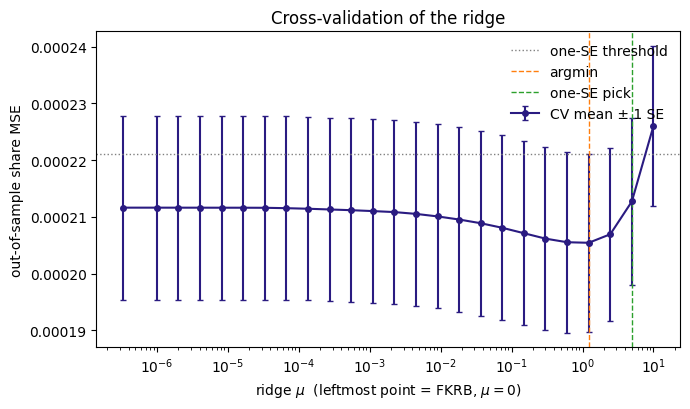

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.2))
m = cv.mu_grid.copy()
m[m == 0] = m[m > 0].min() / 3          # show the mu=0 (FKRB) point on a log axis
ax.errorbar(m, cv.oos_mse_mean, yerr=cv.oos_mse_se, fmt="o-", ms=4, capsize=2,
            color="#2A1B81", label="CV mean ± 1 SE")
i_min = int(np.argmin(cv.oos_mse_mean))
thr = cv.oos_mse_mean[i_min] + cv.oos_mse_se[i_min]
ax.axhline(thr, ls=":", color="grey", lw=1, label="one-SE threshold")
ax.axvline(m[i_min], ls="--", color="C1", lw=1, label="argmin")
ax.axvline(max(cv.mu_1se, m[0]), ls="--", color="C2", lw=1, label="one-SE pick")
ax.set_xscale("log"); ax.set_xlabel(r"ridge $\mu$  (leftmost point = FKRB, $\mu=0$)")
ax.set_ylabel("out-of-sample share MSE"); ax.set_title("Cross-validation of the ridge")
ax.legend(frameon=False); fig.tight_layout()

### Two practical knobs

- **`drop_cols`** — hold a characteristic *homogeneous* (no random coefficient): it is
  excluded from the grid and contributes no heterogeneity. The classic use is price when
  its coefficient is calibrated or weakly identified: `from_fitted(rc, step1, drop_cols=(price_col,))`.
  This shrinks the grid dimension and the number of grid points.
- **`solver`** — the step-2 QP backend. `"cvxpy"` (default, OSQP; needs the `hho` extra)
  or `"pgd"` (a pure-JAX accelerated projected-gradient solver, no cvxpy). They agree; on
  CPU cvxpy is faster, while `"pgd"` is meant for large $R$ on a CUDA GPU.

## 5. A medium-scale example: MLE vs HHO against a known truth

Now a larger market — $J = 31$ products, $T = 200$ markets, $G = 2$, with sampling noise —
where we fit **both** the (correctly specified) normal mixed logit and the HHO
nonparametric estimator, and compare both to the true diversion.

In [10]:
big = simulate(J_in=30, T=200, G=2, n_draws=1000, n_cons=500, seed=7)
print("J =", big["J"], " T =", big["T"], " G =", big["G"])

rc_big = RandomCoefficients(big["avail"], big["q"], x2=big["x2"],
                            nu_i=big["nu"], w_i=big["w"], market_fe=False)
step1_big = rc_big.fit(seed=rng_seed, verbose=False)

fg_big = FixedGridRC.from_fitted(rc_big, step1_big, grid_size=150, span=4.0)
res_big = fg_big.fit(k=10, random_state=rng_seed, select="one_se")
print("selected mu =", f"{res_big.cv.mu_selected:.2e}",
      " | grid points R =", fg_big.beta_grid.shape[0])

J = 31  T = 200  G = 2
RCN
I (Individuals):   1000
J (Products):      31
T (Markets):       200
G (Random Coeffs): 2


selected mu = 2.46e+00  | grid points R = 150


## 6. Substitution: diversion ratios (and elasticities)

The **diversion ratio** $D_{j\to k}$ is the share of consumers leaving product $j$ who
switch to $k$ — the central object for mergers, entry, and competition. With random
coefficients it is a taste-weighted average of individual logit diversions, evaluated at
the baseline ($\xi = 0$, full availability):

$$
D_{jk} \;=\; \mathbb{E}_i\!\left[\frac{s_{ik}}{1-s_{ij}}\cdot \frac{s_{ij}}{s_j}\right]
       \;=\; \sum_i w_i\,\frac{s_{ik}}{1-s_{ij}}\cdot\frac{s_{ij}}{s_j}.
$$

Both `RandomCoefficients` and `FixedGridResult` expose `diversion_matrix()`. Crucially, the
`FixedGridResult` reuses the *same* machinery — its mixing distribution $(\beta_r, \theta_r)$
is just an integration rule (nodes = grid, weights = $\hat\theta$), so its diversion is
directly comparable to the MLE's.

In [11]:
D_mle = np.asarray(rc_big.diversion_matrix(step1_big.x))
D_hho = res_big.diversion_matrix()
D_true = big["D_true"]
off = ~np.eye(big["J"], dtype=bool)


def corr(a, b):
    return np.corrcoef(a[off], b[off])[0, 1]


print(f"corr(MLE, true) = {corr(D_mle, D_true):.4f}")
print(f"corr(HHO, true) = {corr(D_hho, D_true):.4f}")

corr(MLE, true) = 0.9988
corr(HHO, true) = 0.9970


Both should track the truth closely (the DGP really is normal, so the correctly specified
MLE is a strong benchmark; HHO matching it shows going nonparametric costs little here).
A picture makes it concrete — each point is one product pair $(j,k)$:

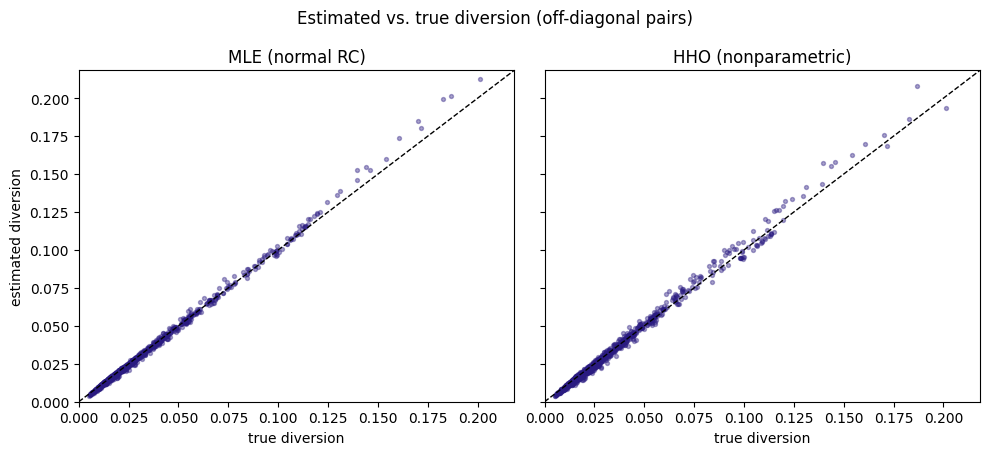

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharex=True, sharey=True)
for ax, D, name in [(axes[0], D_mle, "MLE (normal RC)"), (axes[1], D_hho, "HHO (nonparametric)")]:
    ax.scatter(D_true[off], D[off], s=8, alpha=0.4, color="#2A1B81")
    lim = [0, max(D_true[off].max(), D[off].max()) * 1.05]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("true diversion"); ax.set_title(name)
axes[0].set_ylabel("estimated diversion")
fig.suptitle("Estimated vs. true diversion (off-diagonal pairs)")
fig.tight_layout()

### Visualizing the recovered taste distribution $\hat F(\beta)$

Because $G = 2$, we can *see* what HHO estimated: the grid points $\beta_r$ with positive
weight $\hat\theta_r$, against the true normal density $N(0, \mathrm{diag}\,\sigma^2)$ that
generated the data. (Recall the mean taste lives in $\hat\delta$, so the grid is centered
at the origin — these are deviations.)

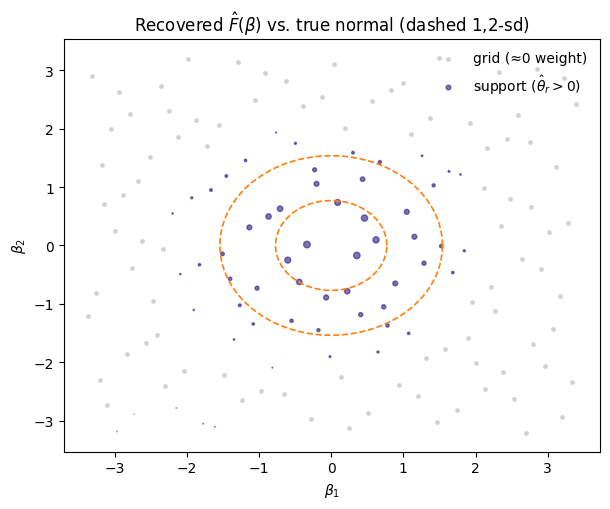

In [13]:
beta_grid, theta_hat = res_big.f_beta()
keep = theta_hat > 1e-4
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.scatter(beta_grid[~keep, 0], beta_grid[~keep, 1], s=6, color="lightgrey", label="grid (≈0 weight)")
sc = ax.scatter(beta_grid[keep, 0], beta_grid[keep, 1], s=400 * theta_hat[keep],
                color="#2A1B81", alpha=0.6, label=r"support ($\hat\theta_r>0$)")
# true 1- and 2-sd ellipses of N(0, diag(sigma^2))
th = np.linspace(0, 2 * np.pi, 200)
for k in (1, 2):
    ax.plot(k * big["sigma_true"][0] * np.cos(th), k * big["sigma_true"][1] * np.sin(th),
            "C1", lw=1.2, ls="--")
ax.set_xlabel(r"$\beta_1$"); ax.set_ylabel(r"$\beta_2$")
ax.set_title(r"Recovered $\hat F(\beta)$ vs. true normal (dashed 1,2-sd)")
ax.legend(frameon=False, loc="upper right"); fig.tight_layout()

The estimated support concentrates where the true normal has mass — HHO recovers the
*shape* without being told it is normal. (More on what is and isn't pinned down in
Section 7.)

### Elasticities (the companion object)

The price-elasticity matrix $\eta_{jk} = \dfrac{\partial s_j}{\partial p_k}\cdot\dfrac{p_k}{s_j}$
is available the same way. With a homogeneous price coefficient $\alpha$ and a price vector
$p$:

In [14]:
prices = np.r_[np.linspace(1.0, 3.0, big["J"] - 1), 0.0]   # arbitrary prices; outside = 0
eta_hho = res_big.elasticity_matrix(prices=prices, price_coeff=-0.8)
print("own-price elasticities (first 5 inside goods):", np.diag(eta_hho)[:5])

RCN
I (Individuals):   150
J (Products):      31
T (Markets):       200
G (Random Coeffs): 2


own-price elasticities (first 5 inside goods): [-0.766 -0.838 -0.897 -0.871 -0.981]


## 7. Identification: what these estimators need, and what they pin down

Two lessons that save a lot of confusion.

### (a) They need *many markets* (with real variation)

The second stage estimates $R$ weights from cross-market variation in shares, so it needs
$T$ large relative to $J$ — the aggregate analogue of FKRB/HHO's many-observations regime.
With sampling noise, recovery degrades sharply when markets are scarce and improves as $T$
grows. We sweep $T$ and watch recovery (correlation with the truth) climb.

T=  10:  corr(MLE,true)=0.977   corr(HHO,true)=0.929


T=  25:  corr(MLE,true)=0.996   corr(HHO,true)=0.997


T=  50:  corr(MLE,true)=0.998   corr(HHO,true)=0.996


T= 100:  corr(MLE,true)=0.995   corr(HHO,true)=0.994


T= 200:  corr(MLE,true)=1.000   corr(HHO,true)=0.996


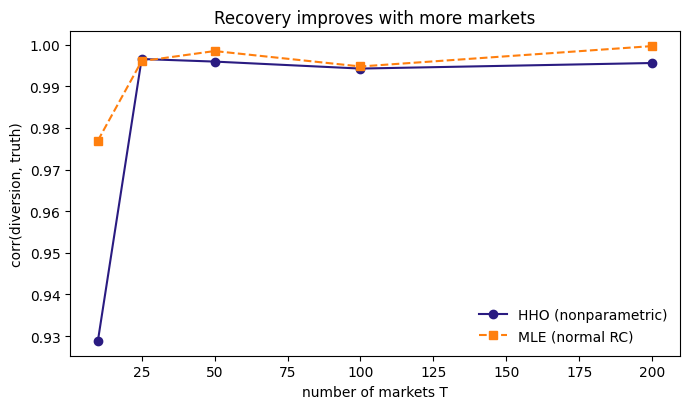

In [15]:
Ts = [10, 25, 50, 100, 200]
rows = []
for T in Ts:
    s = simulate(J_in=12, T=T, G=2, n_cons=300, seed=100 + T)
    with quiet():
        rc_s = RandomCoefficients(s["avail"], s["q"], x2=s["x2"], nu_i=s["nu"], w_i=s["w"])
        st = rc_s.fit(seed=rng_seed, verbose=False)
        r_s = FixedGridRC.from_fitted(rc_s, st, grid_size=120).fit(k=5, random_state=rng_seed)
    o = ~np.eye(s["J"], dtype=bool)
    c_mle = np.corrcoef(np.asarray(rc_s.diversion_matrix(st.x))[o], s["D_true"][o])[0, 1]
    c_hho = np.corrcoef(r_s.diversion_matrix()[o], s["D_true"][o])[0, 1]
    rows.append((T, c_mle, c_hho))
    print(f"T={T:>4}:  corr(MLE,true)={c_mle:.3f}   corr(HHO,true)={c_hho:.3f}")

rows = np.array(rows)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(rows[:, 0], rows[:, 2], "o-", color="#2A1B81", label="HHO (nonparametric)")
ax.plot(rows[:, 0], rows[:, 1], "s--", color="C1", label="MLE (normal RC)")
ax.set_xlabel("number of markets T"); ax.set_ylabel("corr(diversion, truth)")
ax.set_title("Recovery improves with more markets"); ax.legend(frameon=False)
fig.tight_layout()

Note the nonparametric estimator typically converges a bit *slower* than the correctly
specified normal — it pays a variance cost for flexibility, so it needs markets even more.

### (b) Diversion is identified; the raw weights are not

On a dense grid the columns of $Z$ are nearly collinear ($Z^\top Z$ is badly
conditioned), so at $\mu = 0$ the FKRB weight problem has a **non-unique** solution — two
different solvers (or seeds) return different $\hat\theta$. But the **economic object,
diversion, is robust** to which $\hat\theta$ you land on, because different weights that fit
the same shares imply the same substitution. We demonstrate with the two solver backends at
$\mu = 0$.

In [16]:
from logit_mle.fixed_grid import build_design_matrix, grid_to_rc_inputs, solve_qp
from logit_mle.random_coefficients import _diversion_jk

delta_inside = rc_big._unpack_theta(step1_big.x)["delta_inside"]
Z, _ = build_design_matrix(delta_inside, np.zeros(big["T"]), big["x2"],
                           fg_big.beta_grid, big["avail"])
Z = np.asarray(Z)
s_obs = (big["q"] / big["q"].sum(0, keepdims=True)).reshape(-1)
Gram, bvec = Z.T @ Z, Z.T @ s_obs
sigma_vec, nu_full = grid_to_rc_inputs(fg_big.beta_grid, (), big["G"])
af = np.ones((big["J"], 1), dtype=bool)


def div_from_theta(theta):
    return np.asarray(_diversion_jk(delta_inside, sigma_vec, big["x2"], nu_full, theta, af))


th_cvx = solve_qp(Gram, bvec, 0.0, backend="cvxpy")
th_pgd = solve_qp(Gram, bvec, 0.0, backend="pgd", tol=1e-9, max_iter=30000)
o = ~np.eye(big["J"], dtype=bool)
print(f"weights differ:   L1(theta_cvx - theta_pgd) = {np.abs(th_cvx - th_pgd).sum():.3f}")
print(f"diversion agrees: corr = "
      f"{np.corrcoef(div_from_theta(th_cvx)[o], div_from_theta(th_pgd)[o])[0,1]:.4f}")

weights differ:   L1(theta_cvx - theta_pgd) = 0.006
diversion agrees: corr = 1.0000


The takeaway: **report and interpret substitution objects (diversion, elasticities), not
the raw grid weights** — and use a ridge ($\mu > 0$) if you need the distribution itself to
be well-defined.

## 8. When to use what

- **MLE mixed logit vs. HHO** — if you are confident in a parametric taste shape (and want
  the tightest estimates), MLE. If you want to *not* commit to a shape — or to check whether
  normality is driving your substitution conclusions — HHO. They are directly comparable
  because both produce a `diversion_matrix()`.
- **`halton_draws` vs. `sparse_grid`** — Halton by default; sparse grids when $G$ is small
  and heterogeneity is modest (and you have `chaospy`).
- **`solver="cvxpy"` vs. `"pgd"`** — cvxpy/OSQP by default (faster on CPU); `"pgd"` (pure
  JAX, no cvxpy) for very large $R$ on a CUDA GPU.
- **`drop_cols`** — hold a characteristic homogeneous when its random coefficient is
  calibrated or weakly identified (e.g. price), to shrink the grid and stabilize the fit.
- **Above all** — simulate against a known truth, and remember: many markets, and trust
  diversion over weights.